# Vision Foundation Models - Multi-Environment Pipeline

This notebook runs predictions across both environment configurations:
- **`main`**: PyTorch 2.x CUDA 11.8 environment for general vision foundation models.
- **`clipdino`**: PyTorch 1.12.1 + MMSegmentation environment for CLIP-DINOiser.

## 1. Setup Sample Image & Output Directories

Using existing image at: /workspace/datasets/f_img_0.00.png


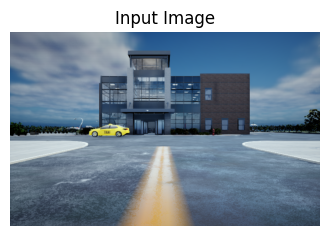

In [6]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Ensure output directories exist
os.makedirs("/workspace/datasets", exist_ok=True)
os.makedirs("/workspace/notebooks/outputs", exist_ok=True)

sample_image_path = "/workspace/datasets/f_img_0.00.png"

# Create a sample image if one does not exist
if not os.path.exists(sample_image_path):
    print("Generating sample test image...")
    img_data = (np.random.rand(448, 448, 3) * 255).astype(np.uint8)
    img = Image.fromarray(img_data)
    img.save(sample_image_path)
    print(f"Sample image created at: {sample_image_path}")
else:
    print(f"Using existing image at: {sample_image_path}")

# Display sample image
plt.figure(figsize=(4, 4))
plt.imshow(Image.open(sample_image_path))
plt.title("Input Image")
plt.axis("off")
plt.show()

## 2. Run Main Models (`main` Environment)

Uses `conda run -n main` to execute predictions using modern PyTorch 2.x foundation models (e.g., standard torchvision models or custom repos in `/workspace/projects`).

In [7]:
%%bash
# Running prediction in the main environment
conda run -n main python3 -c '
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

print("=== [MAIN ENV] Torch Version:", torch.__version__, "===")
print("=== CUDA Available:", torch.cuda.is_available(), "===")

# Load Pre-trained Vision Model
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).eval()
if torch.cuda.is_available():
    model = model.cuda()

# Preprocess Image
img_path = "/workspace/datasets/f_img_0.00.png"
preprocess = weights.transforms()
img = Image.open(img_path).convert("RGB")
batch = preprocess(img).unsqueeze(0)
if torch.cuda.is_available():
    batch = batch.cuda()

# Inference
with torch.no_grad():
    prediction = model(batch).squeeze(0).softmax(0)
    class_id = prediction.argmax().item()
    score = prediction[class_id].item()
    category_name = weights.meta["categories"][class_id]

print(f"[Main Model Output] Predicted Class: '{category_name}' with confidence: {score:.4f}")
'

=== [MAIN ENV] Torch Version: 2.13.0+cu130 ===
=== CUDA Available: False ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
[Main Model Output] Predicted Class: racer with confidence: 0.1167


/opt/conda/envs/main/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0

  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  4%|▎         | 3.50M/97.8M [00:00<00:02, 36.5MB/s]
  8%|▊         | 7.75M/97.8M [00:00<00:02, 41.0MB/s]
 12%|█▏        | 12.1M/97.8M [00:00<00:02, 43.1MB/s]
 17%|█▋        | 16.5M/97.8M [00:00<00:01, 44.1MB/s]
 21%|██        | 20.8M/97.8M [00:00<00:01, 44.3MB/s]
 26%|█���▌       | 25.0M/97.8M [00:00<00:01, 43.9MB/s]
 30%|███       | 29.5M/97.8M [00:00<00:01, 44.9MB/s]
 35%|███▍      | 

## 3. Run CLIP-DINOiser (`clipdino` Environment)

Uses `conda run -n clipdino` to execute `demo.py` from the `clip_dinoiser` repository.

In [8]:
%%bash
# Running prediction in the clipdino environment
conda run -n clipdino python3 -c '
import sys
import torch
import os

print("=== [CLIPDINO ENV] Torch Version:", torch.__version__, "===")
print("=== CUDA Available:", torch.cuda.is_available(), "===")

# Set project directory
repo_dir = "/workspace/projects/clip_dinoiser"
if repo_dir not in sys.path:
    sys.path.append(repo_dir)

os.chdir(repo_dir)

# Run CLI Demo or Model Call
image_path = "/workspace/datasets/sample.jpg"
prompts = "cat,dog,background"

print(f"Running CLIP-DINOiser on '{image_path}' with prompts: [{prompts}]...")
os.system(f"python demo.py --file_path {image_path} --prompts '{prompts}'")
'

=== [CLIPDINO ENV] Torch Version: 2.8.0+cu128 ===
=== CUDA Available: True ===
Running CLIP-DINOiser on /workspace/datasets/sample.jpg with prompts: [cat,dog,background]...


Traceback (most recent call last):
  File "/workspace/projects/clip_dinoiser/demo.py", line 2, in <module>
    from models.builder import build_model
  File "/workspace/projects/clip_dinoiser/models/__init__.py", line 1, in <module>
    from .maskclip import *
  File "/workspace/projects/clip_dinoiser/models/maskclip/__init__.py", line 1, in <module>
    from .maskclip import *
  File "/workspace/projects/clip_dinoiser/models/maskclip/maskclip.py", line 16, in <module>
    from models.builder import MODELS
  File "/workspace/projects/clip_dinoiser/models/builder.py", line 4, in <module>
    from omegaconf import OmegaConf
ModuleNotFoundError: No module named 'omegaconf'


## 4. Visualize Results

In [9]:
import glob

# Check for generated predictions in the outputs or clip_dinoiser directory
generated_masks = glob.glob("/workspace/projects/clip_dinoiser/*.png") + glob.glob("/workspace/notebooks/outputs/*.png")

if generated_masks:
    latest_mask = max(generated_masks, key=os.path.getctime)
    print(f"Displaying output mask: {latest_mask}")
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(Image.open(sample_image_path))
    ax[0].set_title("Original Image")
    ax[0].axis("off")
    
    ax[1].imshow(Image.open(latest_mask))
    ax[1].set_title("CLIP-DINOiser Output Mask")
    ax[1].axis("off")
    plt.show()
else:
    print("No output images found yet. Run the inference cells above.")

No output images found yet. Run the inference cells above.
